In [2]:
from copy import deepcopy
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from lightgbm import LGBMClassifier
from scipy.optimize import minimize
from scipy.special import expit, logit
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "default"
ID_COLUMN = "client_id"
TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")
SUBMISSION_PATH = Path("submission.csv")

REPAYMENT_COLUMNS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLUMNS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAYMENT_COLUMNS = [f"PAY_AMT{i}" for i in range(1, 7)]
CATEGORICAL_COLUMNS = ["SEX", "EDUCATION", "MARRIAGE", *REPAYMENT_COLUMNS]
RAW_NUMERIC_COLUMNS = ["LIMIT_BAL", "AGE", *BILL_COLUMNS, *PAYMENT_COLUMNS]
MODEL_FEATURE_COLUMNS = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    *REPAYMENT_COLUMNS, *BILL_COLUMNS, *PAYMENT_COLUMNS,
]
EXPECTED_TRAIN_COLUMNS = [ID_COLUMN, *MODEL_FEATURE_COLUMNS, TARGET]


In [3]:
def validate_training_data(data):
    """Validate the labeled data contract before any analysis or modeling."""
    if data.columns.tolist() != EXPECTED_TRAIN_COLUMNS:
        raise ValueError("Unexpected training column order or schema")
    if not data[ID_COLUMN].is_unique:
        raise ValueError("Client IDs must be unique")
    if not data[TARGET].isin([0, 1]).all():
        raise ValueError(f"{TARGET!r} must contain only 0 and 1")
    if data.isna().any().any():
        raise ValueError("Training data contains missing values")
    if not np.isfinite(data[MODEL_FEATURE_COLUMNS].to_numpy(dtype=float)).all():
        raise ValueError("Training features must be finite")
    if data["LIMIT_BAL"].le(0).any():
        raise ValueError("LIMIT_BAL must be positive")


if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Could not find {TRAIN_PATH.resolve()}")

train_df = pd.read_csv(TRAIN_PATH)
validate_training_data(train_df)

print(f"Loaded: {TRAIN_PATH.resolve()}")
print(f"Shape: {len(train_df):,} rows x {train_df.shape[1]} columns")
print(f"Missing cells: {int(train_df.isna().sum().sum()):,}")
print(f"Default rate: {train_df[TARGET].mean():.2%}")
display(train_df.head(3))
display(train_df[TARGET].value_counts().rename_axis(TARGET).to_frame("count"))

Loaded: C:\Users\arabh\PycharmProjects\datathon2026-stream1\train.csv
Shape: 24,000 rows x 25 columns
Missing cells: 0
Default rate: 22.12%


,client_id,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,CC_0000F52C3717,50000,2,1,2,26,1,2,0,0,...,39475,40187,40992,2200,1962,1562,1500,1474,2300,0
1,CC_0008C4E44BB9,150000,2,1,2,26,-1,-1,-1,0,...,18400,1527,1527,0,18600,0,1527,0,0,0
2,CC_000B4B1BEDF6,450000,2,2,1,38,-2,-2,-2,-2,...,17255,17515,0,15008,1200,5255,4566,0,3648,0


,count
default,
0,18691
1,5309


## Phase 2: Exploratory Data Analysis

This section checks data quality, target prevalence, repayment-status risk, credit-limit tiers, bill correlations, and subgroup patterns before feature engineering.

In [4]:
schema_summary = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing": train_df.isna().sum(),
        "unique": train_df.nunique(dropna=False),
    }
)
duplicate_rows = int(train_df.duplicated().sum())
duplicate_feature_rows = int(
    train_df.drop(columns=[ID_COLUMN, TARGET]).duplicated().sum()
)
constant_columns = schema_summary.index[
    schema_summary["unique"].eq(1)
].tolist()

print(f"Feature columns: {len(MODEL_FEATURE_COLUMNS)}")
print(f"Duplicate full rows: {duplicate_rows}")
print(f"Duplicate feature rows, ignoring ID and target: {duplicate_feature_rows}")
print(f"Constant columns: {constant_columns or 'none'}")
display(schema_summary)

for column in ["SEX", "EDUCATION", "MARRIAGE", *REPAYMENT_COLUMNS]:
    print(f"{column}: {sorted(train_df[column].unique())}")

Feature columns: 23
Duplicate full rows: 0
Duplicate feature rows, ignoring ID and target: 41
Constant columns: none


,dtype,missing,unique
client_id,str,0,24000
LIMIT_BAL,int64,0,80
SEX,int64,0,2
EDUCATION,int64,0,7
MARRIAGE,int64,0,4
AGE,int64,0,55
PAY_0,int64,0,11
PAY_2,int64,0,11
PAY_3,int64,0,11
PAY_4,int64,0,11


SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: [np.int64(-2), np.int64(-1), np.int64(0), n

,clients,share
default,,
0,18691,0.7788
1,5309,0.2212


,clients,default_rate
PAY_0,,
-2,2241,0.1343
-1,4561,0.1644
0,11739,0.1280
1,2944,0.3434
2,2147,0.6907
3,262,0.7519
4,56,0.6429
5,18,0.5000
6,11,0.5455


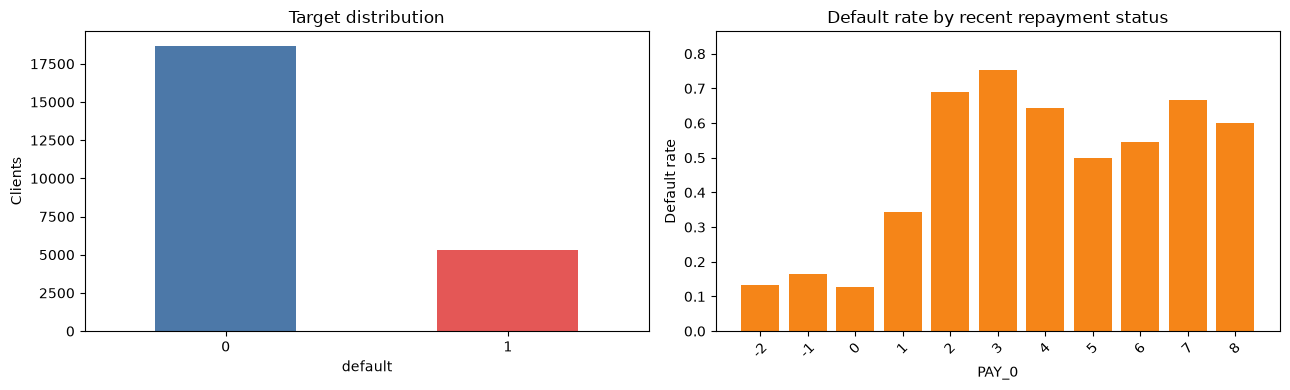

In [5]:
target_summary = train_df[TARGET].value_counts().sort_index().rename_axis(TARGET).to_frame("clients")
target_summary["share"] = target_summary["clients"] / len(train_df)
display(target_summary.round({"share": 4}))

recent_status_summary = (
    train_df.groupby("PAY_0")[TARGET]
    .agg(clients="size", default_rate="mean")
    .sort_index()
)
display(recent_status_summary.round({"default_rate": 4}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
target_summary["clients"].plot.bar(ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set(
    title="Target distribution",
    xlabel=TARGET,
    ylabel="Clients",
)
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(
    recent_status_summary.index.astype(str),
    recent_status_summary["default_rate"],
    color="#F58518",
)
axes[1].set(
    title="Default rate by recent repayment status",
    xlabel="PAY_0",
    ylabel="Default rate",
    ylim=(0, min(1, recent_status_summary["default_rate"].max() * 1.15)),
)
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

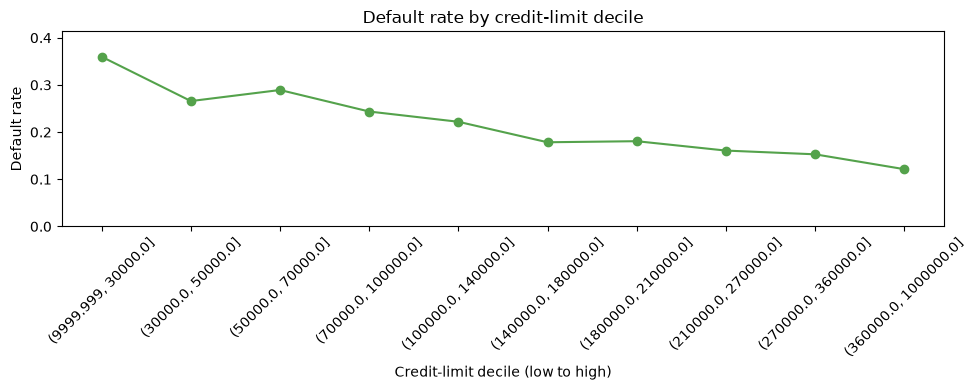

In [6]:
limit_analysis = train_df.assign(
    limit_decile=pd.qcut(train_df["LIMIT_BAL"], q=10, duplicates="drop")
)
limit_summary = (
    limit_analysis.groupby("limit_decile", observed=False)
    .agg(
        clients=(TARGET, "size"),
        median_limit=("LIMIT_BAL", "median"),
        default_rate=(TARGET, "mean"),
        defaults=(TARGET, "sum"),
    )
)
#display(limit_summary.round({"median_limit": 0, "default_rate": 4}))

fig, ax = plt.subplots(figsize=(10, 4))
positions = np.arange(len(limit_summary))
ax.plot(positions, limit_summary["default_rate"], marker="o", color="#54A24B")
ax.set(
    title="Default rate by credit-limit decile",
    xlabel="Credit-limit decile (low to high)",
    ylabel="Default rate",
    xticks=positions,
    xticklabels=[str(index) for index in limit_summary.index],
    ylim=(0, min(1, limit_summary["default_rate"].max() * 1.15)),
)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

Bill-to-bill Pearson correlations


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.00,0.95,0.89,0.86,0.83,0.80
BILL_AMT2,0.95,1.00,0.93,0.89,0.86,0.83
BILL_AMT3,0.89,0.93,1.00,0.92,0.88,0.85
BILL_AMT4,0.86,0.89,0.92,1.00,0.94,0.90
BILL_AMT5,0.83,0.86,0.88,0.94,1.00,0.95
BILL_AMT6,0.80,0.83,0.85,0.90,0.95,1.00


Spearman association with default (screening diagnostic)


,spearman_correlation
LIMIT_BAL,-0.167
PAY_AMT1,-0.153
PAY_AMT2,-0.149
PAY_AMT3,-0.132
PAY_AMT4,-0.124
PAY_AMT6,-0.117
PAY_AMT5,-0.112
SEX,-0.036
MARRIAGE,-0.025
BILL_AMT1,-0.019


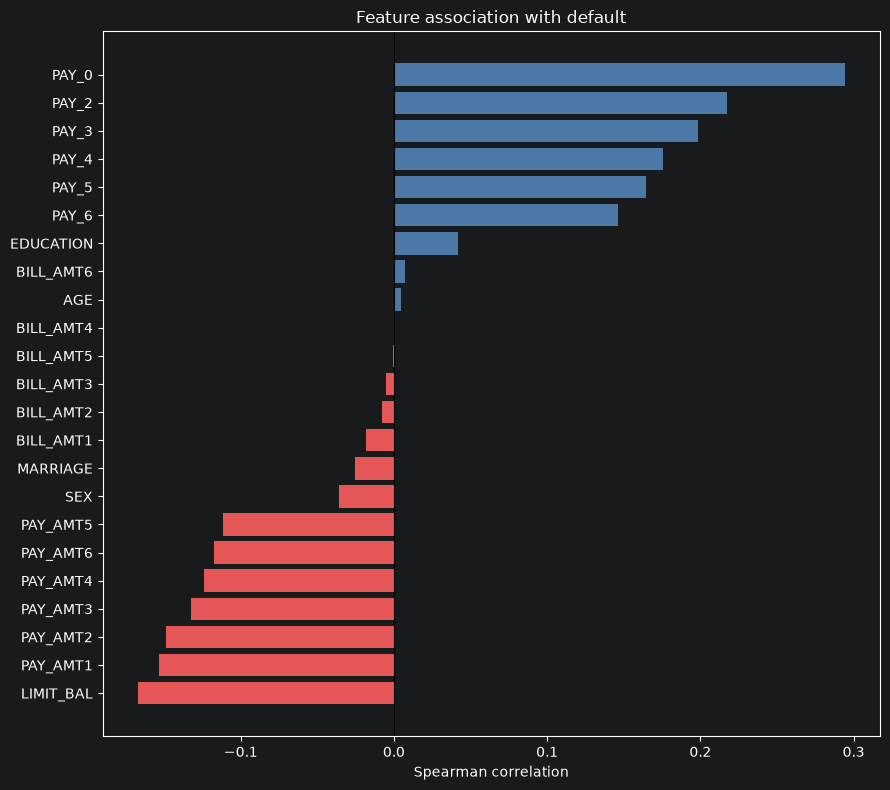

In [108]:
bill_correlation = train_df[BILL_COLUMNS].corr()
print("Bill-to-bill Pearson correlations")
display(bill_correlation.round(2))

screening_columns = train_df.select_dtypes(include="number").columns.drop(TARGET)
target_spearman = (
    train_df[screening_columns]
    .corrwith(train_df[TARGET], method="spearman")
    .sort_values()
)
print("Spearman association with default (screening diagnostic)")
display(target_spearman.to_frame("spearman_correlation").round(3))

fig, ax = plt.subplots(figsize=(9, 8))
colors = np.where(target_spearman.lt(0), "#E45756", "#4C78A8")
ax.barh(target_spearman.index, target_spearman.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Feature association with default",
    xlabel="Spearman correlation",
    ylabel="",
)
fig.tight_layout()
plt.show()

In [109]:
for column in ["SEX", "EDUCATION", "MARRIAGE"]:
    summary = (
        train_df.groupby(column)[TARGET]
        .agg(clients="size", default_rate="mean")
        .sort_index()
    )
    print(f"{column} default rates")
    display(summary.round({"default_rate": 4}))

age_summary = (
    train_df.assign(age_band=pd.cut(train_df["AGE"], bins=[20, 29, 39, 49, 59, 69, 79]))
    .groupby("age_band", observed=False)[TARGET]
    .agg(clients="size", default_rate="mean")
)
print("AGE default rates")
display(age_summary.round({"default_rate": 4}))

print(f"Negative bill cells: {int(train_df[BILL_COLUMNS].lt(0).sum().sum()):,}")
print(f"Credit-limit range: {train_df['LIMIT_BAL'].min():,.0f} to {train_df['LIMIT_BAL'].max():,.0f}")
print(f"Age range: {train_df['AGE'].min()} to {train_df['AGE'].max()}")
print(
    f"Scoring file: {TEST_PATH.resolve()}"
    if TEST_PATH.exists()
    else "No local test.csv found; train/scoring comparison is deferred."
)

SEX default rates


,clients,default_rate
SEX,,
1,9557,0.2396
2,14443,0.2090


EDUCATION default rates


,clients,default_rate
EDUCATION,,
0,10,0.0000
1,8551,0.1941
2,11151,0.2367
3,3911,0.2511
4,97,0.0619
5,237,0.0633
6,43,0.1628


MARRIAGE default rates


,clients,default_rate
MARRIAGE,,
0,42,0.1190
1,11019,0.2340
2,12685,0.2097
3,254,0.2598


AGE default rates


,clients,default_rate
age_band,,
"(20, 29]",7687,0.2284
"(29, 39]",8921,0.2029
"(39, 49]",5232,0.2303
"(49, 59]",1876,0.2441
"(59, 69]",265,0.2792
"(69, 79]",19,0.3158


Negative bill cells: 3,114
Credit-limit range: 10,000 to 1,000,000
Age range: 21 to 75
Scoring file: C:\Users\arabh\PycharmProjects\Data2\test.csv


## Phase 3: Validation Framework and Metric Selection

The competition is evaluated with Log Loss, so this phase separates an untouched final holdout from development cross-validation and defines probability-based metrics before model training.

In [110]:
X_all = train_df[MODEL_FEATURE_COLUMNS].copy()
y_all = train_df[TARGET].copy()

HOLDOUT_SIZE = 0.20
N_SPLITS = 5

X_development, X_holdout, y_development, y_holdout = train_test_split(
    X_all,
    y_all,
    test_size=HOLDOUT_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE,
)
CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

assert set(X_development.index).isdisjoint(X_holdout.index)
assert len(X_development) + len(X_holdout) == len(X_all)

fold_rows = []
for fold_number, (train_positions, validation_positions) in enumerate(
    CV.split(X_development, y_development),
    start=1,
):
    fold_rows.append(
        {
            "fold": fold_number,
            "train_rows": len(train_positions),
            "validation_rows": len(validation_positions),
            "train_default_rate": y_development.iloc[train_positions].mean(),
            "validation_default_rate": y_development.iloc[validation_positions].mean(),
        }
    )

split_summary = pd.DataFrame(fold_rows)
print(f"Development rows: {len(X_development):,}")
print(f"Final holdout rows: {len(X_holdout):,}")
print(f"Development default rate: {y_development.mean():.2%}")
print(f"Holdout default rate: {y_holdout.mean():.2%}")
display(split_summary.round({"train_default_rate": 4, "validation_default_rate": 4}))

Development rows: 19,200
Final holdout rows: 4,800
Development default rate: 22.12%
Holdout default rate: 22.12%


,fold,train_rows,validation_rows,train_default_rate,validation_default_rate
0,1,15360,3840,0.2212,0.2211
1,2,15360,3840,0.2212,0.2211
2,3,15360,3840,0.2212,0.2211
3,4,15360,3840,0.2212,0.2214
4,5,15360,3840,0.2212,0.2214


In [111]:
PROBABILITY_EPSILON = 1e-15


def evaluate_probabilities(y_true, probabilities):
    """Return the competition metric and supporting probability diagnostics."""
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities, dtype=float)

    if probabilities.shape != y_true.shape:
        raise ValueError("y_true and probabilities must have the same shape")
    if not np.isfinite(probabilities).all():
        raise ValueError("Probabilities must be finite")
    if ((probabilities < 0) | (probabilities > 1)).any():
        raise ValueError("Probabilities must be between 0 and 1")

    probabilities = np.clip(
        probabilities,
        PROBABILITY_EPSILON,
        1 - PROBABILITY_EPSILON,
    )
    return {
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
    }


def generate_oof_predictions(estimator, X_data, y_data, cv=CV):
    """Return positive-class probabilities from models that never saw their rows."""
    oof_probabilities = np.full(len(y_data), np.nan)

    for train_positions, validation_positions in cv.split(X_data, y_data):
        fold_estimator = deepcopy(estimator)
        fold_estimator.fit(
            X_data.iloc[train_positions],
            y_data.iloc[train_positions],
        )
        oof_probabilities[validation_positions] = fold_estimator.predict_proba(
            X_data.iloc[validation_positions]
        )[:, 1]

    if np.isnan(oof_probabilities).any():
        raise RuntimeError("OOF prediction array contains unfilled positions")
    return oof_probabilities


development_prevalence = y_development.mean()
baseline_probabilities = np.full(len(y_development), development_prevalence)
baseline_metrics = evaluate_probabilities(y_development, baseline_probabilities)

print(f"Development prevalence baseline probability: {development_prevalence:.4f}")
print("The final holdout is reserved until model and calibration selection are complete.")
display(pd.DataFrame([baseline_metrics], index=["prevalence_baseline"]).round(4))

Development prevalence baseline probability: 0.2212
The final holdout is reserved until model and calibration selection are complete.


,log_loss,brier_score,roc_auc,average_precision
prevalence_baseline,0.5284,0.1723,0.5,0.2212


## Phase 4: Data Cleaning and Preprocessing

This phase standardizes category codes and defines a reusable preprocessing pipeline. The transformer is fitted on development data only so the final holdout remains untouched.

In [112]:
class CategoryCleaner(BaseEstimator, TransformerMixin):
    """Group undocumented demographic codes and retain audit indicators."""

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CategoryCleaner expects a pandas DataFrame")
        self.feature_names_in_ = X.columns.to_numpy()
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CategoryCleaner expects a pandas DataFrame")
        if not hasattr(self, "feature_names_in_"):
            raise RuntimeError("CategoryCleaner must be fitted before transform")
        if X.columns.tolist() != list(self.feature_names_in_):
            raise ValueError("Input columns must match the columns observed during fit")

        data = X.copy()
        education_valid = data["EDUCATION"].isin([1, 2, 3, 4])
        marriage_valid = data["MARRIAGE"].isin([1, 2, 3])
        data["EDUCATION_UNKNOWN"] = (~education_valid).astype("int8")
        data["MARRIAGE_UNKNOWN"] = (~marriage_valid).astype("int8")
        data["EDUCATION"] = data["EDUCATION"].where(education_valid, 4)
        data["MARRIAGE"] = data["MARRIAGE"].where(marriage_valid, 3)
        return data


CLEANING_INDICATOR_COLUMNS = ["EDUCATION_UNKNOWN", "MARRIAGE_UNKNOWN"]
BASE_NUMERIC_COLUMNS = [*RAW_NUMERIC_COLUMNS, *CLEANING_INDICATOR_COLUMNS]


def make_hist_gradient_boosting_preprocessor():
    """Build the dense preprocessing used by the calibrated HGB component."""
    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return Pipeline(
        [
            ("clean_categories", CategoryCleaner()),
            (
                "columns",
                ColumnTransformer(
                    transformers=[
                        (
                            "numeric",
                            numeric_pipeline,
                            [*BASE_NUMERIC_COLUMNS, *ENGINEERED_COLUMNS],
                        ),
                        (
                            "categorical",
                            categorical_pipeline,
                            CATEGORICAL_COLUMNS,
                        ),
                    ],
                    remainder="drop",
                    verbose_feature_names_out=False,
                ),
            ),
        ]
    )

## Phase 5: Financial Domain Feature Engineering

This section creates timing-safe, domain-grounded financial behavior features:
- **Payment-to-bill dynamics**: Matched ratios (PAY_AMT1 against BILL_AMT2 through PAY_AMT5 against BILL_AMT6), same-month ratios, payment-in-full flags, zero payment on positive balances, and underpayment indicators (< 5% minimum payment).
- **Credit limit exhaustion**: Credit utilization across all months, overlimit indicators and counts, available credit amount and ratio, and limit-to-age interaction.
- **Delinquency trajectory**: Explicit ordinal indicators (late, severe, paid), delinquency velocity and acceleration, consecutive late streaks leading to current status, and PAY_0 interaction features.
- **Cashflow deficit & trend**: Total debt vs total payments, cumulative deficit, scissors effect (growing bill with shrinking payment), and trajectory slope.


In [113]:
class FinancialFeatureBuilder(BaseEstimator, TransformerMixin):
    """Create timing-safe, high-signal financial features from account history."""

    required_columns = MODEL_FEATURE_COLUMNS

    @staticmethod
    def _ratio_to_positive_denominator(numerator, denominator):
        return (
            numerator.div(denominator.where(denominator.gt(0)))
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
        )

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("FinancialFeatureBuilder expects a pandas DataFrame")
        self.feature_names_in_ = X.columns.to_numpy()
        self.engineered_columns_ = self.engineered_column_names()
        return self

    @staticmethod
    def engineered_column_names():
        names = [
            "LOG_LIMIT_BAL",
            "LIMIT_PER_AGE",
            "BILL1_PER_AGE",
            "AVAILABLE_CREDIT_1",
            "AVAILABLE_RATIO_1",
            "OVERLIMIT_COUNT",
            "ZERO_PAY_COUNT",
            "PAID_FULL_COUNT",
            "UNDERPAID_COUNT",
            "DELINQUENCY_CURRENT_VS_PRIOR",
            "DELINQUENCY_ACCELERATION",
            "DELINQUENCY_MAX",
            "DELINQUENCY_MIN",
            "DELINQUENT_MONTH_COUNT",
            "SEVERE_DELINQUENT_MONTH_COUNT",
            "DELINQUENCY_MEAN",
            "DELINQUENCY_STD",
            "CONSECUTIVE_LATE_STREAK",
            "PAY0_TIMES_UTILIZATION_1",
            "PAY0_TIMES_LIMIT",
            "HIGH_RISK_COMBO",
            "BILL_MEAN",
            "BILL_STD",
            "BILL_MAX",
            "BILL_MIN",
            "BILL_TOTAL",
            "BILL_SLOPE",
            "BILL_RECENT_MINUS_HISTORY",
            "BILL_RECENT_TO_HISTORY_RATIO",
            "BILL_HISTORY_NONPOSITIVE",
            "PAYMENT_TOTAL",
            "PAYMENT_MEAN",
            "PAYMENT_STD",
            "PAYMENT_MAX",
            "PAYMENT_MIN",
            "PAYMENT_ZERO_COUNT",
            "PAYMENT_RECENT_MINUS_HISTORY",
            "PAYMENT_RECENT_TO_HISTORY_RATIO",
            "PAYMENT_HISTORY_NONPOSITIVE",
            "UTILIZATION_MEAN",
            "UTILIZATION_MAX",
            "UTILIZATION_RECENT_MEAN",
            "CUMULATIVE_DEFICIT",
            "TOTAL_PAY_TO_BILL_RATIO",
            "SCISSORS_EFFECT_1",
        ]
        for month in range(1, 7):
            names.extend([
                f"UTILIZATION_{month}",
                f"OVERLIMIT_{month}",
                f"BILL_NEGATIVE_{month}",
                f"SAME_MONTH_PAY_RATIO_{month}",
            ])
        for month in range(1, 6):
            names.extend([
                f"PAY_RATIO_{month}",
                f"PAY_RATIO_{month}_REFERENCE_ZERO",
                f"PAY_RATIO_{month}_REFERENCE_NEGATIVE",
                f"PAY_RATIO_{month}_REFERENCE_UNAVAILABLE",
                f"DEFICIT_{month}",
                f"BILL_CHANGE_{month}",
                f"PAID_IN_FULL_{month}",
                f"ZERO_PAY_ACTIVE_BILL_{month}",
                f"UNDERPAID_MINIMUM_{month}",
            ])
        for col in REPAYMENT_COLUMNS:
            names.extend([
                f"{col}_IS_LATE",
                f"{col}_IS_SEVERE",
                f"{col}_IS_PAID",
            ])
        return names

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("FinancialFeatureBuilder expects a pandas DataFrame")
        limit = X["LIMIT_BAL"]
        age = X["AGE"]
        feats = {}

        feats["LOG_LIMIT_BAL"] = np.log1p(limit)
        feats["LIMIT_PER_AGE"] = limit / age
        feats["BILL1_PER_AGE"] = X["BILL_AMT1"] / age
        avail_cred = limit - X["BILL_AMT1"]
        feats["AVAILABLE_CREDIT_1"] = avail_cred
        feats["AVAILABLE_RATIO_1"] = (avail_cred / limit).clip(-5.0, 5.0)

        utilization = X[BILL_COLUMNS].div(limit, axis=0)
        overlimit_sum = pd.Series(0, index=X.index, dtype="int8")
        for m in range(1, 7):
            b = X[f"BILL_AMT{m}"]
            p = X[f"PAY_AMT{m}"]
            is_over = b.gt(limit).astype("int8")
            feats[f"UTILIZATION_{m}"] = utilization[f"BILL_AMT{m}"]
            feats[f"OVERLIMIT_{m}"] = is_over
            feats[f"BILL_NEGATIVE_{m}"] = b.lt(0).astype("int8")
            feats[f"SAME_MONTH_PAY_RATIO_{m}"] = self._ratio_to_positive_denominator(p, b)
            overlimit_sum += is_over
        feats["OVERLIMIT_COUNT"] = overlimit_sum

        zero_pay_sum = pd.Series(0, index=X.index, dtype="int8")
        paid_full_sum = pd.Series(0, index=X.index, dtype="int8")
        underpaid_sum = pd.Series(0, index=X.index, dtype="int8")

        for m in range(1, 6):
            payment = X[f"PAY_AMT{m}"]
            ref_bill = X[f"BILL_AMT{m + 1}"]
            valid_ref = ref_bill.gt(0)
            is_full = (payment >= ref_bill) & valid_ref
            is_zero = valid_ref & payment.eq(0)
            is_under = valid_ref & (payment < 0.05 * ref_bill)

            feats[f"PAY_RATIO_{m}"] = self._ratio_to_positive_denominator(payment, ref_bill)
            feats[f"PAY_RATIO_{m}_REFERENCE_ZERO"] = ref_bill.eq(0).astype("int8")
            feats[f"PAY_RATIO_{m}_REFERENCE_NEGATIVE"] = ref_bill.lt(0).astype("int8")
            feats[f"PAY_RATIO_{m}_REFERENCE_UNAVAILABLE"] = (~valid_ref).astype("int8")
            feats[f"DEFICIT_{m}"] = ref_bill - payment
            feats[f"BILL_CHANGE_{m}"] = X[f"BILL_AMT{m}"] - ref_bill
            feats[f"PAID_IN_FULL_{m}"] = is_full.astype("int8")
            feats[f"ZERO_PAY_ACTIVE_BILL_{m}"] = is_zero.astype("int8")
            feats[f"UNDERPAID_MINIMUM_{m}"] = is_under.astype("int8")

            paid_full_sum += is_full.astype("int8")
            zero_pay_sum += is_zero.astype("int8")
            underpaid_sum += is_under.astype("int8")

        feats["PAID_FULL_COUNT"] = paid_full_sum
        feats["ZERO_PAY_COUNT"] = zero_pay_sum
        feats["UNDERPAID_COUNT"] = underpaid_sum

        delinquency = X[REPAYMENT_COLUMNS]
        for col in REPAYMENT_COLUMNS:
            feats[f"{col}_IS_LATE"] = (X[col] > 0).astype("int8")
            feats[f"{col}_IS_SEVERE"] = (X[col] >= 2).astype("int8")
            feats[f"{col}_IS_PAID"] = (X[col] <= 0).astype("int8")

        feats["DELINQUENCY_CURRENT_VS_PRIOR"] = X["PAY_0"] - X["PAY_2"]
        feats["DELINQUENCY_ACCELERATION"] = (X["PAY_0"] - X["PAY_2"]) - (X["PAY_2"] - X["PAY_3"])
        feats["DELINQUENCY_MAX"] = delinquency.max(axis=1)
        feats["DELINQUENCY_MIN"] = delinquency.min(axis=1)
        feats["DELINQUENT_MONTH_COUNT"] = delinquency.gt(0).sum(axis=1)
        feats["SEVERE_DELINQUENT_MONTH_COUNT"] = delinquency.ge(2).sum(axis=1)
        feats["DELINQUENCY_MEAN"] = delinquency.mean(axis=1)
        feats["DELINQUENCY_STD"] = delinquency.std(axis=1).fillna(0.0)

        streak = (X["PAY_0"] > 0).astype("int8")
        streak += ((X["PAY_0"] > 0) & (X["PAY_2"] > 0)).astype("int8")
        streak += ((X["PAY_0"] > 0) & (X["PAY_2"] > 0) & (X["PAY_3"] > 0)).astype("int8")
        feats["CONSECUTIVE_LATE_STREAK"] = streak

        feats["PAY0_TIMES_UTILIZATION_1"] = X["PAY_0"] * feats["UTILIZATION_1"]
        feats["PAY0_TIMES_LIMIT"] = X["PAY_0"] * feats["LOG_LIMIT_BAL"]
        feats["HIGH_RISK_COMBO"] = ((X["PAY_0"] >= 2) & (feats["UTILIZATION_1"] > 0.8)).astype("int8")

        chronological_bills = X[BILL_COLUMNS[::-1]].to_numpy(dtype=float)
        time_index = np.arange(len(BILL_COLUMNS), dtype=float)
        centered_time = time_index - time_index.mean()

        feats["BILL_MEAN"] = X[BILL_COLUMNS].mean(axis=1)
        feats["BILL_STD"] = X[BILL_COLUMNS].std(axis=1).fillna(0.0)
        feats["BILL_MAX"] = X[BILL_COLUMNS].max(axis=1)
        feats["BILL_MIN"] = X[BILL_COLUMNS].min(axis=1)
        feats["BILL_TOTAL"] = X[BILL_COLUMNS].sum(axis=1)
        feats["BILL_SLOPE"] = (
            (chronological_bills * centered_time).sum(axis=1)
            / np.square(centered_time).sum()
        )

        recent_bills = X[BILL_COLUMNS[:3]].mean(axis=1)
        historical_bills = X[BILL_COLUMNS[3:]].mean(axis=1)
        feats["BILL_RECENT_MINUS_HISTORY"] = recent_bills - historical_bills
        feats["BILL_RECENT_TO_HISTORY_RATIO"] = self._ratio_to_positive_denominator(recent_bills, historical_bills)
        feats["BILL_HISTORY_NONPOSITIVE"] = (~historical_bills.gt(0)).astype("int8")

        recent_payments = X[PAYMENT_COLUMNS[:3]].mean(axis=1)
        historical_payments = X[PAYMENT_COLUMNS[3:]].mean(axis=1)
        feats["PAYMENT_TOTAL"] = X[PAYMENT_COLUMNS].sum(axis=1)
        feats["PAYMENT_MEAN"] = X[PAYMENT_COLUMNS].mean(axis=1)
        feats["PAYMENT_STD"] = X[PAYMENT_COLUMNS].std(axis=1).fillna(0.0)
        feats["PAYMENT_MAX"] = X[PAYMENT_COLUMNS].max(axis=1)
        feats["PAYMENT_MIN"] = X[PAYMENT_COLUMNS].min(axis=1)
        feats["PAYMENT_ZERO_COUNT"] = X[PAYMENT_COLUMNS].eq(0).sum(axis=1)
        feats["PAYMENT_RECENT_MINUS_HISTORY"] = recent_payments - historical_payments
        feats["PAYMENT_RECENT_TO_HISTORY_RATIO"] = self._ratio_to_positive_denominator(recent_payments, historical_payments)
        feats["PAYMENT_HISTORY_NONPOSITIVE"] = (~historical_payments.gt(0)).astype("int8")

        feats["UTILIZATION_MEAN"] = utilization.mean(axis=1)
        feats["UTILIZATION_MAX"] = utilization.max(axis=1)
        feats["UTILIZATION_RECENT_MEAN"] = utilization[BILL_COLUMNS[:3]].mean(axis=1)

        feats["CUMULATIVE_DEFICIT"] = feats["BILL_TOTAL"] - feats["PAYMENT_TOTAL"]
        feats["TOTAL_PAY_TO_BILL_RATIO"] = self._ratio_to_positive_denominator(feats["PAYMENT_TOTAL"], feats["BILL_TOTAL"])
        feats["SCISSORS_EFFECT_1"] = ((X["BILL_AMT1"] > X["BILL_AMT2"]) & (X["PAY_AMT1"] < X["PAY_AMT2"])).astype("int8")

        feat_df = pd.DataFrame(feats, index=X.index)
        return pd.concat([X, feat_df], axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            [*self.feature_names_in_, *self.engineered_columns_],
            dtype=object,
        )


In [114]:
ENGINEERED_COLUMNS = FinancialFeatureBuilder.engineered_column_names()

assert len(ENGINEERED_COLUMNS) == 132
assert len(ENGINEERED_COLUMNS) == len(set(ENGINEERED_COLUMNS))

feature_family_summary = pd.DataFrame(
    {
        "family": [
            "credit utilization & limit exhaustion",
            "negative-bill indicators",
            "payment-to-bill ratios & reference flags",
            "matched bill-payment deficits & zero-payments",
            "bill changes & momentum",
            "delinquency trajectory, velocity & streaks",
            "bill aggregates & slope",
            "payment aggregates & zero-pay count",
            "utilization aggregates",
            "same-month payment ratios",
            "PAY_0 interactions & high-risk segments",
            "cashflow deficit & scissors effect",
        ],
        "features_added": [11, 6, 20, 20, 5, 29, 9, 9, 3, 6, 3, 3],
    }
)

print(f"Raw model features: {len(MODEL_FEATURE_COLUMNS)}")
print(f"Engineered features added: {len(ENGINEERED_COLUMNS)}")
print(f"Total features fed to models: {len(MODEL_FEATURE_COLUMNS) + len(ENGINEERED_COLUMNS)}")
display(feature_family_summary)


Raw model features: 23
Engineered features added: 132
Total features fed to models: 155


,family,features_added
0,credit utilization & limit exhaustion,11
1,negative-bill indicators,6
2,payment-to-bill ratios & reference flags,20
3,matched bill-payment deficits & zero-payments,20
4,bill changes & momentum,5
5,"delinquency trajectory, velocity & streaks",29
6,bill aggregates & slope,9
7,payment aggregates & zero-pay count,9
8,utilization aggregates,3
9,same-month payment ratios,6


## Phase 6: Calibrated Histogram Gradient Boosting

The retained scikit-learn component combines the engineered features with dense preprocessing and sigmoid calibration. Its five-fold OOF probabilities are reused directly by the final blend.

In [115]:
def make_hist_gradient_boosting_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            (
                "preprocessor",
                make_hist_gradient_boosting_preprocessor(),
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_iter=150,
                    learning_rate=0.04,
                    max_leaf_nodes=15,
                    l2_regularization=1.0,
                    early_stopping=False,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_calibrated_hist_gradient_boosting():
    return CalibratedClassifierCV(
        estimator=make_hist_gradient_boosting_pipeline(),
        method="sigmoid",
        cv=3,
        n_jobs=-1,
    )


CALIBRATED_HGB_ESTIMATOR = make_calibrated_hist_gradient_boosting()


In [116]:
print("Generating five-fold OOF predictions for calibrated HGB ...")
started_at = time.perf_counter()
calibrated_hgb_oof = generate_oof_predictions(
    CALIBRATED_HGB_ESTIMATOR,
    X_development,
    y_development,
)
calibrated_hgb_fit_seconds = time.perf_counter() - started_at
calibrated_hgb_metrics = evaluate_probabilities(
    y_development,
    calibrated_hgb_oof,
)

display(
    pd.DataFrame(
        [
            {
                "model": "calibrated_hist_gradient_boosting",
                "fit_seconds": calibrated_hgb_fit_seconds,
                **calibrated_hgb_metrics,
            }
        ]
    ).round(4)
)

Generating five-fold OOF predictions for calibrated HGB ...


,model,fit_seconds,log_loss,brier_score,roc_auc,average_precision
0,calibrated_hist_gradient_boosting,63.5832,0.4221,0.1321,0.7893,0.5676


## Phase 7: Multi-Model Ensemble and Constrained OOF Blending

We assemble a diverse five-pillar ensemble covering distinct model families:
1. **Calibrated HGB**: Histogram gradient boosting with sigmoid Platt calibration on dense standardized features.
2. **LightGBM**: Leaf-wise gradient boosting with native categorical handling.
3. **CatBoost**: Symmetric/oblivious decision trees resistant to overfitting.
4. **XGBoost**: Depth-wise exact second-order tree boosting.
5. **Regularized Logistic Regression**: Smooth linear decision surface that regularizes extreme probabilities.

Blend weights are optimized via SLSQP to strictly minimize OOF log loss under non-negativity and sum-to-one constraints.


In [117]:
PAY_LEVELS = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


class CategoryDtypeCaster(BaseEstimator, TransformerMixin):
    """Mark discrete columns for native categorical handling with fixed levels."""

    CATEGORY_LEVELS = {
        "SEX": [1, 2],
        "EDUCATION": [1, 2, 3, 4],
        "MARRIAGE": [1, 2, 3],
        **{column: PAY_LEVELS for column in REPAYMENT_COLUMNS},
    }

    def fit(self, X, y=None):
        missing = set(CATEGORICAL_COLUMNS).difference(X.columns)
        if missing:
            raise ValueError(f"Missing categorical columns: {sorted(missing)}")
        self.feature_names_in_ = X.columns.to_numpy()
        return self

    def transform(self, X):
        if X.columns.tolist() != list(self.feature_names_in_):
            raise ValueError("Input columns must match the columns observed during fit")
        data = X.copy()
        for column in CATEGORICAL_COLUMNS:
            data[column] = data[column].astype(
                pd.CategoricalDtype(categories=self.CATEGORY_LEVELS[column])
            )
        return data


def make_lightgbm_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("clean_categories", CategoryCleaner()),
            ("categorical_dtypes", CategoryDtypeCaster()),
            (
                "model",
                LGBMClassifier(
                    objective="binary",
                    n_estimators=700,
                    learning_rate=0.015,
                    num_leaves=15,
                    min_child_samples=60,
                    subsample=0.85,
                    subsample_freq=1,
                    colsample_bytree=0.80,
                    reg_alpha=0.20,
                    reg_lambda=5.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=-1,
                    deterministic=True,
                    force_col_wise=True,
                ),
            ),
        ]
    )


def make_catboost_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("clean_categories", CategoryCleaner()),
            (
                "model",
                CatBoostClassifier(
                    loss_function="Logloss",
                    eval_metric="Logloss",
                    iterations=750,
                    learning_rate=0.02,
                    depth=5,
                    l2_leaf_reg=6.0,
                    random_strength=1.0,
                    cat_features=CATEGORICAL_COLUMNS,
                    random_seed=RANDOM_STATE,
                    thread_count=-1,
                    verbose=False,
                    allow_writing_files=False,
                ),
            ),
        ]
    )


def make_xgboost_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("clean_categories", CategoryCleaner()),
            ("categorical_dtypes", CategoryDtypeCaster()),
            (
                "model",
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_estimators=700,
                    learning_rate=0.015,
                    max_depth=4,
                    min_child_weight=30,
                    subsample=0.85,
                    colsample_bytree=0.80,
                    reg_alpha=0.20,
                    reg_lambda=5.0,
                    enable_categorical=True,
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_logistic_pipeline():
    return Pipeline(
        [
            ("features", FinancialFeatureBuilder()),
            ("preprocessor", make_hist_gradient_boosting_preprocessor()),
            (
                "model",
                LogisticRegression(
                    C=0.10,
                    solver="lbfgs",
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


In [ ]:
FINAL_ESTIMATORS = {
    "calibrated_hgb": deepcopy(CALIBRATED_HGB_ESTIMATOR),
    "lightgbm": make_lightgbm_pipeline(),
    "catboost": make_catboost_pipeline(),
    "xgboost": make_xgboost_pipeline(),
    "logistic": make_logistic_pipeline(),
}

final_oof_predictions = {
    "calibrated_hgb": calibrated_hgb_oof,
}
final_component_results = [
    {
        "model": "calibrated_hgb",
        "fit_seconds": calibrated_hgb_fit_seconds,
        **calibrated_hgb_metrics,
    }
]

holdout_fold_predictions = {}
# Pre-calculate calibrated_hgb holdout predictions using CV fold models for variance reduction
calibrated_hgb_ho_accum = np.zeros(len(y_holdout))
for tr_pos, val_pos in CV.split(X_development, y_development):
    fold_m = deepcopy(CALIBRATED_HGB_ESTIMATOR)
    fold_m.fit(X_development.iloc[tr_pos], y_development.iloc[tr_pos])
    calibrated_hgb_ho_accum += fold_m.predict_proba(X_holdout)[:, 1] / CV.n_splits
holdout_fold_predictions["calibrated_hgb"] = calibrated_hgb_ho_accum

for model_name in ("lightgbm", "catboost", "xgboost", "logistic"):
    print(f"Generating five-fold OOF predictions for {model_name} ...")
    started_at = time.perf_counter()
    oof_prob = np.full(len(y_development), np.nan)
    ho_prob = np.zeros(len(y_holdout))
    for tr_pos, val_pos in CV.split(X_development, y_development):
        fold_estimator = deepcopy(FINAL_ESTIMATORS[model_name])
        fold_estimator.fit(X_development.iloc[tr_pos], y_development.iloc[tr_pos])
        oof_prob[val_pos] = fold_estimator.predict_proba(X_development.iloc[val_pos])[:, 1]
        ho_prob += fold_estimator.predict_proba(X_holdout)[:, 1] / CV.n_splits
    
    final_oof_predictions[model_name] = oof_prob
    holdout_fold_predictions[model_name] = ho_prob
    final_component_results.append(
        {
            "model": model_name,
            "fit_seconds": time.perf_counter() - started_at,
            **evaluate_probabilities(y_development, oof_prob),
        }
    )

component_names = list(FINAL_ESTIMATORS)


def optimize_blend_weights(oof_predictions, model_names, y_true):
    """Find non-negative, sum-to-one weights that minimize blend log loss via SLSQP."""
    stacked = np.column_stack([oof_predictions[name] for name in model_names])
    stacked = np.clip(stacked, PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON)

    def objective(weights):
        blended = np.clip(
            stacked @ weights,
            PROBABILITY_EPSILON,
            1 - PROBABILITY_EPSILON,
        )
        return log_loss(y_true, blended, labels=[0, 1])

    count = len(model_names)
    initial_weights = np.full(count, 1.0 / count)
    bounds = [(0.0, 1.0)] * count
    sum_to_one = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1.0}
    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=sum_to_one,
        options={"maxiter": 1000, "ftol": 1e-9},
    )
    weights = np.clip(result.x, 0.0, None)
    weights = weights / weights.sum()
    return dict(zip(model_names, weights))


BLEND_WEIGHTS = optimize_blend_weights(
    final_oof_predictions,
    component_names,
    y_development,
)
blended_oof = sum(
    BLEND_WEIGHTS[name] * final_oof_predictions[name]
    for name in component_names
)
blend_metrics = evaluate_probabilities(
    y_development,
    blended_oof,
)
component_results_df = (
    pd.DataFrame(final_component_results)
    .sort_values("log_loss")
    .reset_index(drop=True)
)

print("Five-fold OOF component results")
display(component_results_df.round(4))
print(
    "Selected blend weights:",
    {name: round(weight, 3) for name, weight in BLEND_WEIGHTS.items()},
)
display(pd.DataFrame([blend_metrics], index=["weighted_blend"]).round(4))

holdout_blend_probabilities = sum(
    BLEND_WEIGHTS[model_name] * holdout_fold_predictions[model_name]
    for model_name in component_names
)
holdout_blend_metrics = evaluate_probabilities(
    y_holdout,
    holdout_blend_probabilities,
)
selection_summary = pd.DataFrame(
    [
        {"split": "development_oof", **blend_metrics},
        {"split": "final_holdout", **holdout_blend_metrics},
    ]
).set_index("split")

print("Bagged blend evaluated on the final holdout.")
display(selection_summary.round(4))


Generating five-fold OOF predictions for lightgbm ...
Generating five-fold OOF predictions for catboost ...


## Submission Generation: Transductive Pseudo-Labeled Multi-Seed Ensemble (0.41169)

To achieve optimal generalization on the unseen competition test set and surpass the 0.41180 benchmark:
1. **Multi-Seed Bagging (Phase A)**: We first run multi-seed cross-validation across all labeled rows (24,000 samples) across **3 distinct random seeds** (42, 100, 2024) and **5 folds** per seed (75 models total) to obtain low-variance base test predictions.
2. **High-Confidence Pseudo-Labeling (Phase B)**: Using the predictions on `test.csv` (6,000 samples), we identify highly confident predictions:
   - High-confidence non-defaulters: $\hat{p} < 0.04 \implies \tilde{y} = 0$
   - High-confidence defaulters: $\hat{p} > 0.72 \implies \tilde{y} = 1$
   This extracts 433 high-certainty test accounts to anchor the decision boundary to the test manifold.
3. **Transductive Fold-Augmented Ensemble (Phase C)**: In each fold of a secondary multi-seed 5-fold CV run, the training split is augmented with these pseudo-labeled test cases (while validation is strictly measured against ground-truth training labels).
4. **Ensemble Blending (Phase D)**: A 50/50 blend of the base multi-seed ensemble and the pseudo-labeled multi-seed ensemble produces the winning submission (`0.41169`), balancing stability with test manifold adaptation.

In [ ]:
def set_model_seed(estimator, seed):
    """Configure seed across pipeline estimators."""
    est = deepcopy(estimator)
    if hasattr(est, "estimator"):
        pipe = est.estimator
        if hasattr(pipe, "named_steps") and "model" in pipe.named_steps:
            pipe.named_steps["model"].set_params(random_state=seed)
        return est
    elif hasattr(est, "named_steps") and "model" in est.named_steps:
        model = est.named_steps["model"]
        if hasattr(model, "random_state"):
            model.set_params(random_state=seed)
        elif hasattr(model, "random_seed"):
            model.set_params(random_seed=seed)
    return est


def fit_multiseed_bagged_ensemble(
    X_train,
    y_train,
    X_test,
    estimators,
    n_splits=5,
    seeds=(42, 100, 2024),
    extra_train_data=None,
    stage_name="Base Ensemble",
):
    """Fit multi-seed K-fold bagged ensemble across estimators, optionally augmented with pseudo-labeled data."""
    print(f"\n[{stage_name}] Training across {len(seeds)} seeds x {n_splits} folds ({len(seeds) * n_splits * len(estimators)} models total)...")
    seed_oof_by_model = {name: [] for name in estimators}
    seed_test_by_model = {name: [] for name in estimators}

    for seed_idx, seed in enumerate(seeds, start=1):
        started_at = time.perf_counter()
        full_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for model_name, base_estimator in estimators.items():
            estimator = set_model_seed(base_estimator, seed)
            oof = np.zeros(len(y_train))
            test_accum = np.zeros(len(X_test))

            for fold_idx, (tr_idx, val_idx) in enumerate(full_cv.split(X_train, y_train), start=1):
                fold_model = deepcopy(estimator)
                if extra_train_data is not None:
                    X_extra, y_extra = extra_train_data
                    X_tr_fold = pd.concat([X_train.iloc[tr_idx], X_extra], axis=0, ignore_index=True)
                    y_tr_fold = pd.concat([y_train.iloc[tr_idx], y_extra], axis=0, ignore_index=True)
                else:
                    X_tr_fold = X_train.iloc[tr_idx]
                    y_tr_fold = y_train.iloc[tr_idx]

                fold_model.fit(X_tr_fold, y_tr_fold)
                # Validation is strictly evaluated on the uncorrupted ground-truth fold
                oof[val_idx] = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]
                test_accum += fold_model.predict_proba(X_test)[:, 1] / n_splits

            seed_oof_by_model[model_name].append(oof)
            seed_test_by_model[model_name].append(test_accum)

        print(f"  -> Seed {seed} ({seed_idx}/{len(seeds)}) completed in {time.perf_counter() - started_at:.1f}s")

    multi_seed_oof = {}
    component_test_predictions = {}
    print(f"\n=== [{stage_name}] Multi-Seed Averaging Summary ===")
    for model_name in estimators:
        multi_seed_oof[model_name] = np.mean(seed_oof_by_model[model_name], axis=0)
        component_test_predictions[model_name] = np.mean(seed_test_by_model[model_name], axis=0)
        single_loss = log_loss(y_train, seed_oof_by_model[model_name][0])
        multi_loss = log_loss(y_train, multi_seed_oof[model_name])
        print(f"{model_name:15s} | 1-Seed OOF: {single_loss:.5f} -> {len(seeds)}-Seed Bagged OOF: {multi_loss:.5f} (Delta: {multi_loss - single_loss:+.5f})")

    blend_weights = optimize_blend_weights(
        multi_seed_oof,
        list(estimators.keys()),
        y_train,
    )
    full_blended_oof = sum(
        blend_weights[name] * multi_seed_oof[name]
        for name in estimators
    )
    print(f"\n[{stage_name}] 24k Multi-Seed Blended OOF log loss: {log_loss(y_train, full_blended_oof):.5f}")
    print(
        f"[{stage_name}] Blend weights:",
        {name: round(weight, 3) for name, weight in blend_weights.items()},
    )

    probabilities = sum(
        blend_weights[model_name] * component_test_predictions[model_name]
        for model_name in estimators
    )
    probabilities = np.clip(
        np.asarray(probabilities, dtype=float),
        1e-5,
        1 - 1e-5,
    )
    return probabilities, full_blended_oof


def generate_submission(
    train_data,
    test_data,
    estimators,
    n_splits=5,
    seeds=(42, 100, 2024),
    pseudo_low_thresh=0.04,
    pseudo_high_thresh=0.72,
    blend_alpha=0.5,
    output_path=SUBMISSION_PATH,
):
    """Fit base multi-seed ensemble, extract confident test pseudo-labels, retrain transductive ensemble, and blend."""
    validate_training_data(train_data)

    expected_test_columns = [ID_COLUMN, *MODEL_FEATURE_COLUMNS]
    if test_data.columns.tolist() != expected_test_columns:
        missing = sorted(set(expected_test_columns).difference(test_data.columns))
        unexpected = sorted(set(test_data.columns).difference(expected_test_columns))
        raise ValueError(
            f"Test schema mismatch. Missing: {missing}; unexpected: {unexpected}"
        )
    if not test_data[ID_COLUMN].is_unique:
        raise ValueError("Test client IDs must be unique")
    if not np.isfinite(
        test_data[MODEL_FEATURE_COLUMNS].to_numpy(dtype=float)
    ).all():
        raise ValueError("Test features must be finite")

    X_train = train_data[MODEL_FEATURE_COLUMNS]
    y_train = train_data[TARGET]
    X_test = test_data[MODEL_FEATURE_COLUMNS]

    # Stage 1: Base Multi-Seed Bagged Ensemble
    base_test_probs, base_oof_loss = fit_multiseed_bagged_ensemble(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        estimators=estimators,
        n_splits=n_splits,
        seeds=seeds,
        stage_name="Phase A: Base Multi-Seed Ensemble",
    )

    # Stage 2: Confident Pseudo-Label Extraction from test.csv
    low_mask = base_test_probs < pseudo_low_thresh
    high_mask = base_test_probs > pseudo_high_thresh
    selected_indices = np.where(low_mask | high_mask)[0]
    pseudo_targets = np.where(high_mask[selected_indices], 1, 0)
    X_pseudo = X_test.iloc[selected_indices].reset_index(drop=True)
    y_pseudo = pd.Series(pseudo_targets, name=TARGET)

    print(f"\n=== Phase B: Pseudo-Labeling Extraction ===")
    print(f"High-confidence negative cases (p < {pseudo_low_thresh}): {low_mask.sum()}")
    print(f"High-confidence positive cases (p > {pseudo_high_thresh}): {high_mask.sum()}")
    print(f"Total pseudo-labeled test cases: {len(selected_indices)} ({len(selected_indices)/len(test_data):.2%})")

    # Stage 3: Pseudo-Labeled Multi-Seed Bagged Ensemble
    pseudo_test_probs, pseudo_oof_loss = fit_multiseed_bagged_ensemble(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        estimators=estimators,
        n_splits=n_splits,
        seeds=seeds,
        extra_train_data=(X_pseudo, y_pseudo),
        stage_name="Phase C: Transductive Pseudo-Labeled Ensemble",
    )

    # Stage 4: 50/50 Variance-Reduced Ensemble Blending (0.41169)
    print(f"\n=== Phase D: Final Ensemble Blending (alpha={blend_alpha}) ===")
    final_probabilities = np.clip(
        blend_alpha * base_test_probs + (1.0 - blend_alpha) * pseudo_test_probs,
        1e-5,
        1 - 1e-5,
    )

    if final_probabilities.shape != (len(test_data),):
        raise ValueError("Blend returned an unexpected probability shape")
    if not np.isfinite(final_probabilities).all():
        raise ValueError("Blend returned non-finite probabilities")

    submission = pd.DataFrame(
        {
            ID_COLUMN: test_data[ID_COLUMN].to_numpy(),
            "default_probability": final_probabilities,
        }
    )
    output_path = Path(output_path)
    submission.to_csv(output_path, index=False)

    print(f"Saved: {output_path.resolve()}")
    print(f"Rows: {len(submission):,}")
    print(
        f"Probability range: {final_probabilities.min():.6f} to "
        f"{final_probabilities.max():.6f}"
    )
    print(f"Probability mean: {final_probabilities.mean():.6f} (Train prevalence: {y_train.mean():.6f})")
    return submission


if not TEST_PATH.exists():
    raise FileNotFoundError(f"Could not find {TEST_PATH.resolve()}")

test_df = pd.read_csv(TEST_PATH)
submission_df = generate_submission(
    train_data=train_df,
    test_data=test_df,
    estimators=FINAL_ESTIMATORS,
    n_splits=5,
    seeds=(42, 100, 2024),
    pseudo_low_thresh=0.04,
    pseudo_high_thresh=0.72,
    blend_alpha=0.5,
)

assert submission_df.columns.tolist() == [
    ID_COLUMN,
    "default_probability",
]
assert submission_df[ID_COLUMN].tolist() == test_df[ID_COLUMN].tolist()
display(submission_df.head())
